In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of devnagari digit.zip" /content/

In [ ]:
!ls /content/

'Copy of Copy of devnagari digit.zip'   drive   sample_data


In [ ]:
import zipfile

zip_path = "/content/Copy of Copy of devnagari digit.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['DevanagariHandwrittenDigitDataset']


In [ ]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset

Test  Train


In [ ]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset/Train

digit_0  digit_2  digit_4  digit_6  digit_8
digit_1  digit_3  digit_5  digit_7  digit_9


In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Manual Gradient Calculation in NumPy

In [ ]:
import numpy as np

# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x

# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1

for _ in range(10):  # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)

print(f"x: {x}, f(x): {f(x)}")

x: 0.5368709120000001, f(x): 0.2882303761517119


Gradient Computation with Keras

In [ ]:
import tensorflow as tf

x = tf.Variable(5.0)  # Trainable variable

with tf.GradientTape() as tape:
    y = x ** 2  # y = x^2

grad = tape.gradient(y, x)  # Computes dy/dx automatically

print(grad.numpy())  # Output: 10.0

10.0


Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU)

In [ ]:
import numpy as np
import tensorflow as tf
import time

# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)

# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.06665420532226562
TensorFlow Time: 0.13654732704162598


Implementation of Activation Function with Keras.

In [ ]:
from tensorflow.keras.layers import Dense

layer = Dense(64, activation='sigmoid')

Manually Training Network in Numpy

In [ ]:
import numpy as np

# Dummy data (just for demonstration)
x_train = np.random.rand(100, 3)
y_train = np.random.rand(100, 1)

# Initialize weights
weights = np.random.rand(3, 1)

# Learning rate
learning_rate = 0.01

In [ ]:
for epoch in range(10):
    # Forward pass
    y_pred = np.dot(x_train, weights)

    # Compute loss
    loss = np.mean((y_pred - y_train) ** 2)

    # Compute gradients manually
    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

    # Update weights
    weights -= learning_rate * gradients

In [ ]:
#model.fit(x_train, y_train, epochs=10, batch_size=32)

Understanding Fully Connected Layers

In [ ]:
from tensorflow.keras.layers import Dense

layer = Dense(64, activation="sigmoid")

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid") # 64 neurons with sigmoid activation

Building a Simple Fully Connected Neural Network in Keras

Training set: (12120, 28, 28, 1), Labels: (12120, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


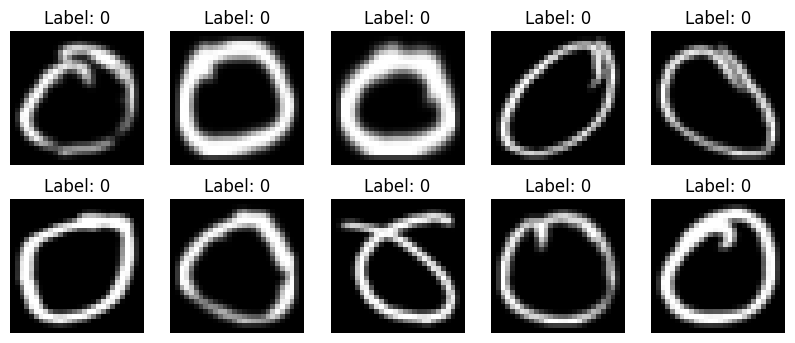

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# DEFINE DATASET PATH
train_dir = "/content/drive/MyDrive/devnagari_data/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/devnagari_data/DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # digit_0, digit_1, ...
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image
            img = Image.open(img_path).convert("L")

            # Resize
            img = img.resize((img_width, img_height))

            # Normalize
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print shapes
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

Loading and Preprocessing MNIST Handwritten Digit Dataset

In [ ]:
# Loading and Preprocessing MNIST Handwritten Digit Dataset
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

Build the Model

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras

num_classes = 10
input_shape = (28*28),

model = keras.Sequential(
[
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compiling and Training the Model

In [ ]:
model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
batch_size = 128
epochs = 2000

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)

Epoch 1/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1134 - loss: 2.3069 - val_accuracy: 0.1016 - val_loss: 2.3034
Epoch 2/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1156 - loss: 2.3015 - val_accuracy: 0.1002 - val_loss: 2.3010
Epoch 3/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1173 - loss: 2.3000 - val_accuracy: 0.0993 - val_loss: 2.2994
Epoch 4/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1196 - loss: 2.2986 - val_accuracy: 0.1790 - val_loss: 2.2981
Epoch 5/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1232 - loss: 2.2970 - val_accuracy: 0.1063 - val_loss: 2.2965
Epoch 6/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1286 - loss: 2.2949 - val_accuracy: 0.1093 - val_loss: 2.2938
Epoch 7/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1356 - loss: 2.2931 - val_accuracy: 0.1063 - val_loss: 2.2918
Epoch 8/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1349 - loss: 2.2909 - 

# Visualization of Model’s Training Progress

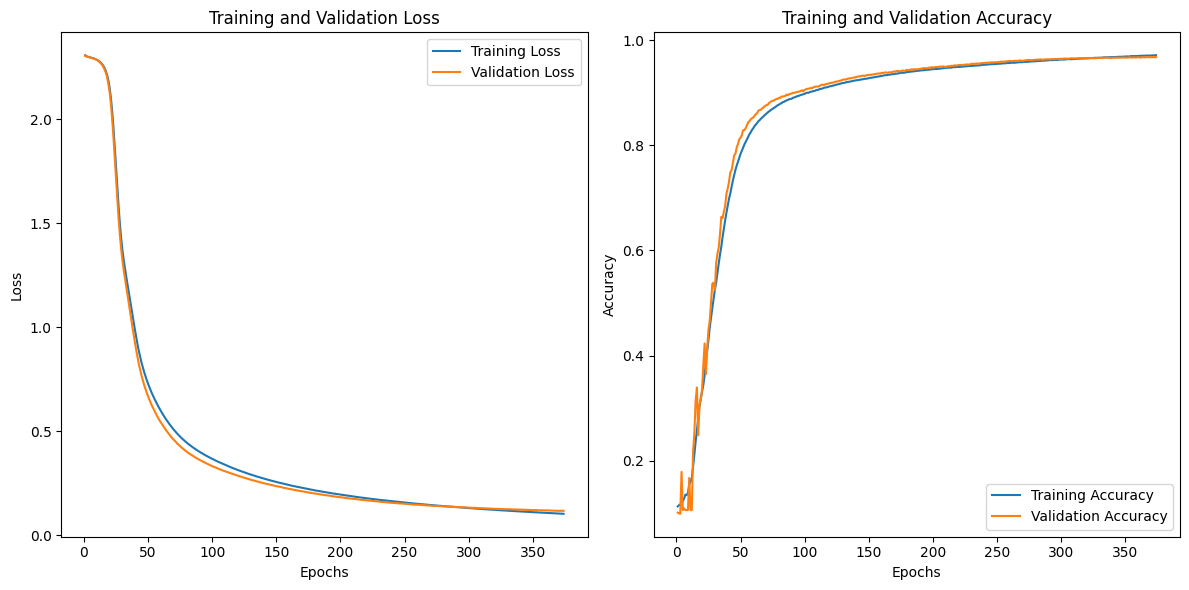

In [ ]:
import matplotlib.pyplot as plt

# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extracting training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plotting training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9625 - loss: 0.1295
Test accuracy: 0.9625


# Making Predictions with Keras

In [ ]:
# Predict on test data
predictions = model.predict(x_test)

# Convert predictions to labels
predicted_labels = np.argmax(predictions, axis=1)

# Check first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image: 7


Saving and Loading the Model

In [ ]:
# Save the model
model.save('mnist_fully_connected_model.h5')

In [ ]:
# Load the model
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

In [ ]:
# Evaluate loaded model
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"Loaded Model Test accuracy: {test_acc:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.9625 - loss: 0.1295
Loaded Model Test accuracy: 0.9625


# Task 2: Build the FCN Model

In [ ]:
from tensorflow import keras

num_classes = 10
input_shape = (28*28,)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Task 4: Train the Model

In [ ]:
batch_size = 128
epochs = 20

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6835 - loss: 1.0372 - val_accuracy: 0.8989 - val_loss: 0.3648
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9106 - loss: 0.3132 - val_accuracy: 0.9250 - val_loss: 0.2606
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9321 - loss: 0.2313 - val_accuracy: 0.9398 - val_loss: 0.2090
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9461 - loss: 0.1827 - val_accuracy: 0.9509 - val_loss: 0.1730
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9550 - loss: 0.1522 - val_accuracy: 0.9552 - val_loss: 0.1538
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9620 - loss: 0.1281 - val_accuracy: 0.9584 - val_loss: 0.1407
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9662 - loss: 0.1129 - val_accuracy: 0.9601 - val_loss: 0.1353
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9713 - loss: 0.0982 - val_accuracy: 0.

# Task 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9708 - loss: 0.1197
Test accuracy: 0.9708


# Task 6: Save and Load the Model

In [ ]:
# Save the model
model.save('devnagari_fcn_model.h5')

# Load the model
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')

# Evaluate loaded model
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"Loaded Model Test accuracy: {test_acc:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.9708 - loss: 0.1197
Loaded Model Test accuracy: 0.9708


# Task 7: Make Predictions

In [ ]:
# Predict on test data
predictions = model.predict(x_test)

# Convert predictions to labels
predicted_labels = np.argmax(predictions, axis=1)

# Check first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image: 7
